
# Decision Trees

*(Partially retrieved from https://stackabuse.com/decision-trees-in-python-with-scikit-learn/)*

## 1. Introduction

A decision tree is one of most frequently and widely used supervised machine learning algorithms that can perform both <u>regression</u> and <u>classification</u> tasks. The intuition behind the decision tree algorithm is simple, yet also very powerful.

<span style="color:red">For each attribute in the dataset, the decision tree algorithm forms a tree, where the most important attribute is placed at the root node.</span> <span style="color:blue">For evaluation we start at the root node and work our way down the tree by following the corresponding node that meets our condition or "decision". This process continues until a leaf node is reached, which contains the prediction or the outcome of the decision tree.</span>

This may sound a bit complicated at first, but what you probably don't realize is that you have been using decision trees to make decisions your entire life without even knowing it. 

Consider a scenario where a person asks you to lend them your car for a day, and you have to make a decision whether or not to lend them the car. There are several factors that help determine your decision, some of which have been listed below:

1. Is this person a close friend or just an acquaintance? If the person is just an acquaintance, then decline the request; if the person is friend, then move to next step.
2. Is the person asking for the car for the first time? If so, lend them the car, otherwise move to next step.
3. Was the car damaged last time they returned the car? If yes, decline the request; if no, lend them the car.

The decision tree for the aforementioned scenario looks like this:

<img src="https://s3.amazonaws.com/stackabuse/media/decision-trees-python-scikit-learn-1.png" width="500">

### The CART (Classification And Regression Tree) Model 
The representation for the CART model is a binary tree. Each root node represents a single input variable (x) and a split point on that variable (assuming the variable is numeric).

The leaf nodes of the tree contain an output variable (y) which is used to make a prediction.

Given a new input, the tree is traversed by evaluating the specific input started at the root node of the tree.

#### Some **advantages** of decision trees are:
* Simple to understand and to interpret. Trees can be visualised.
* Requires little data preparation. 
* Able to handle both numerical and categorical data.
* Possible to validate a model using statistical tests. 
* Performs well even if its assumptions are somewhat violated by the true model from which the data were generated.
* They're very fast and efficient compared to other classification algorithms.

#### The **disadvantages** of decision trees include:
* Overfitting. Mechanisms such as setting the minimum number of samples required at a leaf node or setting the maximum depth of the tree are necessary to avoid this problem.
* Cannot guarantee to return the globally optimal decision tree. Mitigant: Training multiple trees in an ensemble learner.
* Decision tree learners create biased trees if some classes dominate. Recommendation: Balance the dataset prior to fitting.

## 2. Implementing Decision Trees with Python Scikit Learn
In this section, we will implement the decision tree algorithm using Python's Scikit-Learn library. In the following examples we'll solve both classification as well as regression problems using the decision tree.

## 2.1 Decision Tree for Classification

In this section we will predict whether a bank note is authentic or fake depending upon four different attributes of the image of the note. The attributes are Variance of wavelet transformed image, curtosis of the image, entropy, and skewness of the image.

For more detailed information about this dataset, check out the UCI ML repo for this dataset (https://archive.ics.uci.edu/ml/datasets/banknote+authentication)

The steps to implement this algorithm in Scikit-Learn are identical to any typical machine learning problem. We will: 
1) import libraries and datasets, 
2) perform some data analysis, 
3) divide the data into training and testing sets, 
4) train the algorithm, make predictions, 
5) and finally we will evaluate the algorithm's performance on our dataset.

**Import libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

**Importing the Dataset**

Since our file is in CSV format, we will use panda's read_csv method to read our CSV data file. Execute the following script to do so:

In [2]:
dataset = pd.read_csv("bill_authentication.csv")

**Data Analysis**

Execute the following command to see the number of rows and columns in our dataset:

In [3]:
dataset.shape

(1372, 5)

The output will show "(1372,5)", which means that our dataset has 1372 records and 5 attributes.

Execute the following command to inspect the first five records of the dataset:

In [4]:
dataset.head()

,Variance,Skewness,Curtosis,Entropy,Class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


The target variable here will be the column ``Class`` which values are only:
- 0: Authentic
- 1: Fake

**Preparing the Data**

In this section we will divide our data into attributes and labels and will then divide the resultant data into both training and test sets. By doing this we can train our algorithm on one set of data and then test it out on a completely different set of data that the algorithm hasn't seen yet. This provides an accurate view of how your trained algorithm will actually perform.

To divide data into attributes and labels, execute the following code:

In [5]:
X = dataset.drop('Class', axis='columns')
y = dataset['Class']

Here the ``X`` variable contains all the columns from the dataset, except the ``Class`` column, which is the label. The ``y`` variable contains the values from the ``Class`` column. The ``X`` variable is our attribute set and ``y`` variable contains corresponding labels.

The final preprocessing step is to divide our data into training and test sets. The ``model_selection`` library of Scikit-Learn contains ``train_test_split`` method, which we'll use to randomly split the data into training and testing sets. Execute the following code to do so:

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify=y, random_state=1)

In the code above, the ``test_size`` parameter specifies the ratio of the test set, which we use to split up 20% of the data in to the test set and 80% for training.

**Training and Making Predictions**

Once the data has been divided into the training and testing sets, the final step is to train the decision tree algorithm on this data and make predictions. Scikit-Learn contains the ``tree library``, which contains built-in classes/methods for various decision tree algorithms. Since we are going to perform a classification task here, we will use the ``DecisionTreeClassifier`` class for this example. The ``fit`` method of this class is called to train the algorithm on the training data, which is passed as parameter to the ``fit`` method. Execute the following script to train the algorithm:

In [7]:
from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier(random_state=5)
classifier.fit(X_train, y_train)

# colocar imagem da arvore (graphviz)

DecisionTreeClassifier(random_state=5)

Now that our classifier has been trained, let's make predictions on the test data. To make predictions, the predict method of the ``DecisionTreeClassifier`` class is used. Take a look at the following code for usage:

In [8]:
y_pred = classifier.predict(X_test)

**Evaluating the Algorithm**

At this point we have trained our algorithm and made some predictions. Now we'll see how accurate our algorithm is. For classification tasks some commonly used metrics are confusion matrix, precision, recall, and F1 score. Lucky for us Scikit-Learn's metrics library contains the ``classification_report`` and ``confusion_matrix`` methods that can be used to calculate these metrics for us:

In [9]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred, labels=[0,1])
confusion = pd.DataFrame(cm, index=['authentic', 'fake'],
                         columns=['predicted authentic','predicted fake'])
confusion

,predicted authentic,predicted fake
authentic,152,1
fake,3,119


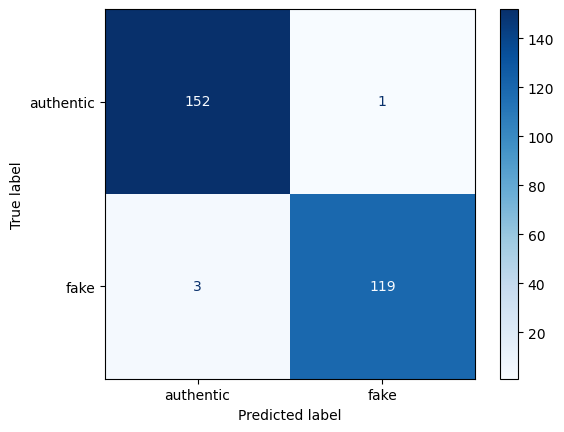

In [10]:
cm_fig = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['authentic', 'fake'])
cm_fig.plot(cmap='Blues')

# alternative: display the confusion matrix with seaborn
#import seaborn as sns
#sns.heatmap(confusion, annot=True, fmt="d")

In [11]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       153
           1       0.99      0.98      0.98       122

    accuracy                           0.99       275
   macro avg       0.99      0.98      0.99       275
weighted avg       0.99      0.99      0.99       275



From the confusion matrix, you can see that out of 275 test instances, our algorithm misclassified only 4. This is 99 % accuracy. Not too bad!

## 2.2 Decision Tree for Regression

The process of solving regression problem with decision tree using Scikit Learn is very similar to that of classification. However for regression we use DecisionTreeRegressor class of the tree library. Also the evaluation matrics for regression differ from those of classification. The rest of the process is almost same.

**Dataset**

We will use this dataset to try and predict gas consumptions (in millions of gallons) in 48 US states based upon gas tax (in cents), per capita income (dollars), paved highways (in miles) and the proportion of population with a drivers license.

The dataset is available at this link: https://people.sc.fsu.edu/~jburkardt/datasets/regression/x16.txt

The first two columns in the above dataset do not provide any useful information, therefore they have been removed from the dataset file.

Now let's apply our decision tree algorithm on this data to try and predict the gas consumption from this data.

In [12]:
dataset = pd.read_csv('petrol_consumption.csv')
dataset.head()

,Petrol_tax,Average_income,Paved_Highways,Population_Driver_licence(%),Petrol_Consumption
0,9.0,3571,1976,0.525,541
1,9.0,4092,1250,0.572,524
2,9.0,3865,1586,0.580,561
3,7.5,4870,2351,0.529,414
4,8.0,4399,431,0.544,410


To see statistical details of the dataset, execute the following command:

In [13]:
dataset.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Petrol_tax,48.0,7.668333,0.950770,5.000,7.00000,7.5000,8.12500,10.000
Average_income,48.0,4241.833333,573.623768,3063.000,3739.00000,4298.0000,4578.75000,5342.000
Paved_Highways,48.0,5565.416667,3491.507166,431.000,3110.25000,4735.5000,7156.00000,17782.000
Population_Driver_licence(%),48.0,0.570333,0.055470,0.451,0.52975,0.5645,0.59525,0.724
Petrol_Consumption,48.0,576.770833,111.885816,344.000,509.50000,568.5000,632.75000,968.000


**Preparing the Data**

As with the classification task, in this section we will divide our data into attributes and labels and consequently into training and test sets.

Execute the following commands to divide data into labels and attributes:

In [14]:
X = dataset.drop('Petrol_Consumption', axis=1)
y = dataset['Petrol_Consumption']

Here the ``X`` variable contains all the columns from the dataset, except ``Petrol_Consumption`` column, which is the label. The ``y`` variable contains values from the ``Petrol_Consumption`` column, which means that the ``X`` variable contains the attribute set and ``y`` variable contains the corresponding labels.

Execute the following code to divide our data into training and test sets:

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

**Training and Making Predictions**

As mentioned earlier, for a regression task we'll use a different sklearn class than we did for the classification task. The class we'll be using here is the ``DecisionTreeRegressor`` class, as opposed to the ``DecisionTreeClassifier`` from before.

To train the tree, we'll instantiate the ``DecisionTreeRegressor`` class and call the fit method:

In [16]:
from sklearn.tree import DecisionTreeRegressor
regressor = DecisionTreeRegressor(random_state=3)

regressor.fit(X_train, y_train)

DecisionTreeRegressor(random_state=3)

To make predictions on the test set, ues the predict method:

In [17]:
y_pred = regressor.predict(X_test)

In [18]:
y_pred

array([541., 414., 574., 554., 631., 644., 648., 540., 414., 510.])

**Evaluating the Algorithm**

To evaluate performance of the regression algorithm, the commonly used metrics are mean absolute error, mean squared error, and root mean squared error. The Scikit-Learn library contains functions that can help calculate these values for us. To do so, use this code from the metrics package:

In [ ]:
from sklearn import metrics
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print('R2 Score: ', metrics.r2_score(y_test, y_pred))

Mean Absolute Error: 47.6
Mean Squared Error: 4271.8
Root Mean Squared Error: 65.35900856041194
R2 Score:  0.2709542208811764


The mean absolute error for our algorithm is 47.0, which is less than **10 percent** of the mean of all the values in the ``Petrol_Consumption`` column. This means that our algorithm did a fine prediction job.